# Welcome! Please upload the file you wish to work with!
## File Upload Directions.

### 1. On the left column of the webpage you will find an upload icon that looks like this. Click on it and upload your file.

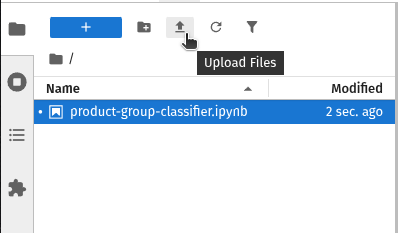

### 2. Once you have uploaded the file, right-click or command-click to get a context menu and select 'Copy Path.' This information will be used when interacting with the program. Specifically, you will need to paste the path into the program prompt.

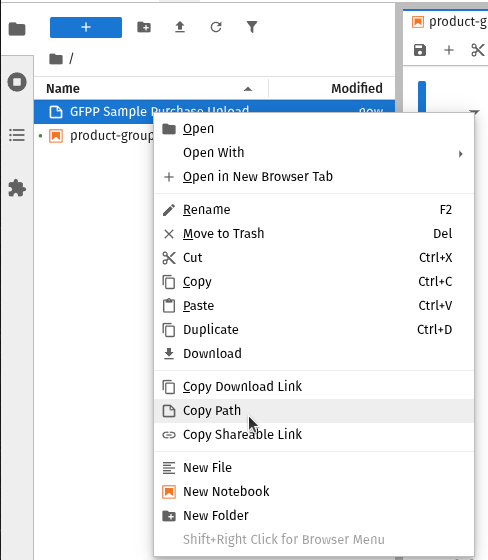

### 3. Change the value of `INPUT` to the path to your file (be sure to keep the quotes). If your data are not on the fourth sheet in the Excel file, change the `SHEET_NUMBER` as well.

In [ ]:
# Set this to the filepath of your uploaded excel file
# You can get this by uploading the file, then right clicking and selecting "Copy path"
# INPUT = "Name Normalization_Combined_Example.xlsx"
INPUT = "GFPP Sample Purchase Upload_6.10.25 (1).xlsx"
SHEET_NUMBER = 4

### 4. Run all the cells in the notebook, either with Run → Run All Cells or with Kernel → Restart Kernel and Run All Cells.

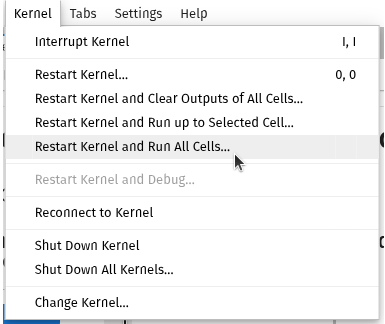

In [ ]:
from huggingface_hub import notebook_login
import pandas as pd
from datasets import Dataset
from sklearn.model_selection import train_test_split
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer
from transformers import pipeline
from transformers import AutoTokenizer
from transformers import DataCollatorWithPadding
from transformers import AutoModel
import evaluate
import numpy as np
import json
import warnings

warnings.filterwarnings("ignore")

In [ ]:
import keras
import tensorflow

In [ ]:
print(keras.__version__)

In [ ]:
model_reloaded = AutoModel.from_pretrained("anth0nyhak1m/demo_model")
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")
classifier = pipeline("text-classification", model="anth0nyhak1m/FPC_model")
ss_classifier = pipeline("text-classification", model="anth0nyhak1m/SS_model")

In [ ]:
def classify_text(text, classifier):
    # Assuming 'classifier' is the function that predicts the labels
    classification = classifier(text)
    predicted_label, confidence = classification[0].values()
    return predicted_label, confidence

# Change Unique ID to Center Product ID
def apply_classifier_to_column(df, text_column_name, classifier, ss_classifier):
    # Apply the 'classify_text' function to each row in the specified column
    # if 'Unique Id' in df.columns:
    #     df = df[['Unique Id',text_column_name]]
    # else:
    df = df[[text_column_name]]

    df.dropna(inplace=True)
    df.reset_index(drop=True, inplace=True)
    # something = df[text_column_name].apply(lambda x: classify_text(text=x, classifier=classifier)).apply(pd.Series)
    # print(something)
    df[['predicted_label_0', 'confidence_score_0']] = df[text_column_name].apply(lambda x: classify_text(text=x, classifier=classifier)).apply(pd.Series)
    df[['predicted_label_1', 'confidence_score_1']] = df[text_column_name].apply(lambda x: classify_text(text=x, classifier=ss_classifier)).apply(pd.Series)

    # if 'Unique Id' in df.columns:
    #     return df[['Unique Id', text_column_name, 'predicted_label_0', 'confidence_score_0', 'predicted_label_1', 'confidence_score_1']]
    # else:
    return df[[text_column_name, 'predicted_label_0', 'confidence_score_0', 'predicted_label_1', 'confidence_score_1']]

def upload_classified_dataset(data, column_name):
    while True:
        try:
            classified_data = apply_classifier_to_column(data, column_name, classifier, ss_classifier)
            print("!DATA CLASSIFICATION HAS SUCCEEDED----------------------------------------DATA CLASSIFICATION HAS SUCCEEDED----------------------------------------DATA CLASSIFICATION HAS SUCCEEDED!")
            return classified_data
        except KeyError:
            print("There was a KeyError thrown, please double-check the column name, Remember, column names are CASE SENSITIVE!")
        except ValueError:
            print("There was a ValueError thrown, please double-check the column name, Remember, column values MUST be character strings!")

def highlight_uncertain_preds(df, threshold=.85):
  """Creates a styles dictionary for underconfident predictions"""
  styles_dict = {}
  for col_idx, dtype in enumerate(df.dtypes):
    # TODO: this is fragile - fix it later
    if dtype == 'object':
      continue
    else:
      try:
        styles_dict[df.columns[col_idx - 1]] = df.iloc[:,col_idx].apply(lambda x: 'background-color: yellow' if x < threshold else '')
      except:
        print(f"Tried to find uncertainty in a a non-float column! {df.iloc[:,col_idx].head(5)}")
  return styles_dict

# Make sure that name capitalizations match so 'turkey, other poultry != Turkey, Other Poultry'
# Include Parameter to specify size of dataset that you want to pass
def main(input, input_column, sheet_name=0, output="classified_data", raw=False, rows_to_classify=None):
  try:
    data = pd.read_excel(input, sheet_name=sheet_name)
  except FileNotFoundError:
      print("There was a FileNotFoundError thrown, please double-check the file name, or ensure that you have correctly uploaded the file.")

  if rows_to_classify:
    data = data.head(rows_to_classify)

  df = upload_classified_dataset(data, input_column)

  # Highlight uncertain predictions
  styles_dict = highlight_uncertain_preds(df)
  styles_df = pd.DataFrame(styles_dict)

  # TODO: Hack to rename model output columns to match name normalization names
  rename_dict = {
      "predicted_label_0": "Primary Food Product Category",
      "predicted_label_1": "Packaging",
  }
  df.rename(columns=rename_dict, inplace=True)
  styles_df.rename(columns=rename_dict, inplace=True)

  if not raw:
    # Match columns to name normalization tool
    name_normalization_cols = ["Center Product ID", "Product Type", "Primary Food Product Category", "Basic Type", "Sub-type 1", "Sub-type 2", "Flavor/Cut", "Shape", "Skin", "Seed/Bone", "Processing", "Cooked/Cleaned", "WG/WGR", "Dietary Concern", "Additives", "Dietary Accommodation", "Frozen", "Packaging", "Commodity"]
    for col in name_normalization_cols:
      if col not in df.columns:
        df[col] = ""
      if col not in styles_df.columns:
        styles_df[col] = ""
    df = df[name_normalization_cols]
    styles_df = styles_df[name_normalization_cols]

  # Actually apply the styles — have to do this after all other df manipulation since applying styles gives you a Styler object not a dataframe
  df_styled = df.style.apply(lambda x: styles_df, axis=None)
  output_suffix = "_raw.xlsx" if raw else ".xlsx"
  output_file = output + output_suffix
  df_styled.to_excel(output_file, index=False)

  print(f"Please download {output} from the Files menu on the left!")

In [ ]:
# This displays the columns in your dataset (Assumes that the file is an Excel file)
df = pd.read_excel(INPUT, nrows=5, sheet_name=SHEET_NUMBER)
for col in df.columns:
  print(col)

In [ ]:
df["Product Type"]

In [ ]:
# This is the name of the column that contains the text you would like classified
# You can copy and paste from the column names above
INPUT_COLUMN = "Product Type"

In [ ]:
# Set this to the number of rows you would like to classify in the dataset
# If you want to classify all rows, set this to None (Counterintuitive, but this defaults to all rows if this value is empty)
ROWS_TO_CLASSIFY = None

# Setting this to True will output the raw classification data (including model confidence scores)
# Setting this to False will remove the model confidence scores
# (Without the model confidence scores, this displays in the name normalization format)
# RAW = False
RAW = True

In [ ]:
main(input=INPUT, sheet_name=SHEET_NUMBER, input_column=INPUT_COLUMN, rows_to_classify=ROWS_TO_CLASSIFY, raw=RAW)

### 5. If you see a 'Data Classification has Succeeded' message in the prompts above, this means that your file was successfully classified, and should appear underneath the files tab under the name; 'Classified_Data.xlsx'. Download it with the context menu.

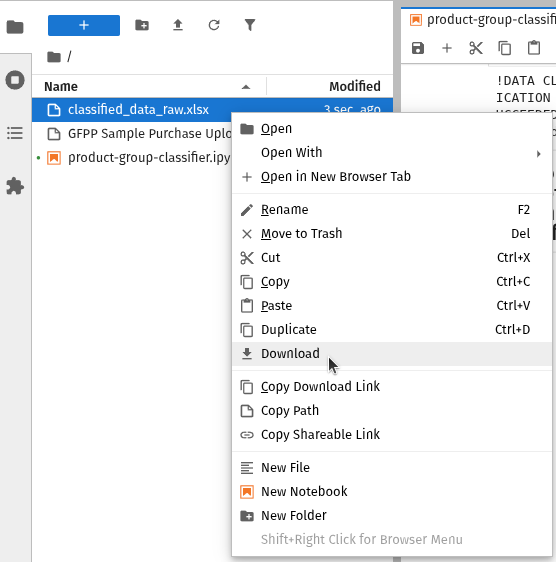